<a href="https://colab.research.google.com/github/Trieu1020/baitapANN/blob/main/ANN5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
import shutil
from tqdm import tqdm

def organize_images_by_label(source_dir, target_root):
    os.makedirs(target_root, exist_ok=True)

    for filename in tqdm(os.listdir(source_dir)):
        if filename.endswith(('.jpg', '.jpeg', '.png')):
            label = filename.split('_')[0]
            label_dir = os.path.join(target_root, label)
            os.makedirs(label_dir, exist_ok=True)

            src = os.path.join(source_dir, filename)
            dst = os.path.join(label_dir, filename)

            shutil.copy(src, dst)

# Đường dẫn tới folder chứa ảnh training và validation
train_folder = '/content/drive/MyDrive/Food-11 (2)/Food-11/training'
val_folder   = '/content/drive/MyDrive/Food-11 (2)/Food-11/validation'

# Thư mục đầu ra đã phân loại
sorted_train_folder = '/content/sorted_food/train'
sorted_val_folder   = '/content/sorted_food/val'

organize_images_by_label(train_folder, sorted_train_folder)
organize_images_by_label(val_folder, sorted_val_folder)


100%|██████████| 3430/3430 [01:34<00:00, 36.15it/s]


In [4]:
import pandas as pd
import numpy as np
from keras.datasets import cifar100
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from keras.utils import to_categorical

train_path = '/content/sorted_food/train'
val_path = '/content/sorted_food/val'

IMG_SIZE = 32
BATCH_SIZE = 8

datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

Found 9876 images belonging to 11 classes.
Found 3430 images belonging to 11 classes.


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(train_data.num_classes, activation='softmax')
])


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 70s 55ms/step - accuracy: 0.1419 - loss: 2.5151 - val_accuracy: 0.1478 - val_loss: 2.3020
Epoch 2/10
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - accuracy: 0.1595 - loss: 2.2895 - val_accuracy: 0.1776 - val_loss: 2.2694
Epoch 3/10
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - accuracy: 0.1644 - loss: 2.2774 - val_accuracy: 0.1831 - val_loss: 2.2618
Epoch 4/10
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - accuracy: 0.1655 - loss: 2.2782 - val_accuracy: 0.1738 - val_loss: 2.2683
Epoch 5/10
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 66s 53ms/step - accuracy: 0.1630 - loss: 2.2750 - val_accuracy: 0.1927 - val_loss: 2.2433
Epoch 6/10
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 61s 49ms/step - accuracy: 0.1660 - loss: 2.2667 - val_accuracy: 0.1875 - val_loss: 2.2454
Epoch 7/10
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 58s 47ms/step - accuracy: 0.1722 - loss: 2.2753 - val_accuracy: 0.1895 - val_loss: 2.2590
Epoch 8/10
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 66s 54ms/step - accuracy: 0.1744 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
Loại 10


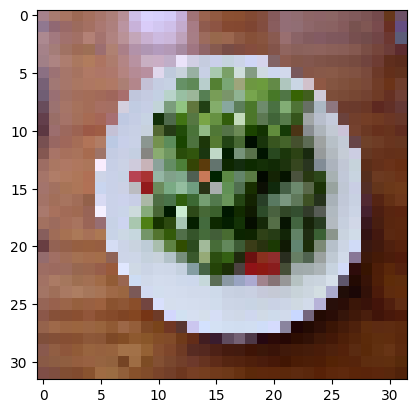

In [7]:
from keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np

url = '/content/drive/MyDrive/Food-11 (2)/Food-11/evaluation/10_104.jpg'
img=load_img(url,target_size=(32,32))
plt.imshow(img)
img_array=img_to_array(img)/255
img_flatten=img_array.reshape(1,32,32,3)
prediction=model.predict(img_flatten)
print('Loại',np.argmax(prediction))